# How to load a dataset
This notebook demonstrates how to load datasets in different ways.

In [ ]:
from histokit.dataset import Dataset

camelyon16_dataset = Dataset.from_index(
    "../data/camelyon16/index.csv",
    "../data/camelyon16/labels.json",
)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def show_image(img, cmap=None, dpi=100):
    if isinstance(img, Image.Image):
        img = np.asarray(img)

    h, w = img.shape[:2]

    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])  # fill entire figure

    ax.imshow(img, cmap=cmap, interpolation="nearest")
    ax.set_axis_off()

    plt.show()

In [3]:
def show_image_pp(img):
    """Display an image in a pixel perfect way"""
    h, w = img.shape
    dpi = 100

    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])

    ax.imshow(img, interpolation="nearest")
    ax.set_axis_off()

    plt.show()

100%|██████████| 108186/108186 [00:24<00:00, 4460.35it/s]


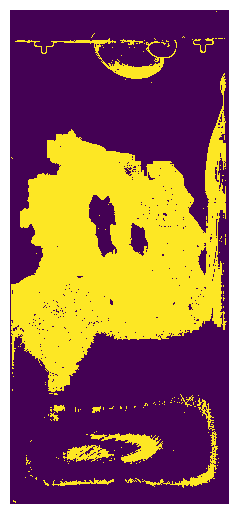

In [4]:
from histokit.segmentation.detectors import (
    per_patch_canny_segmentation,
)


LEVEL = 8

for sample in camelyon16_dataset.samples():
    with sample.open_slide() as slide:
        thumbnail = slide.get_thumbnail(LEVEL)
        downsample = slide.level_downsamples()[LEVEL]
        # foreground_mask = clam_segmentation_otsu(5, LEVEL)(slide)
        foreground_mask = per_patch_canny_segmentation(patch_level=1, patch_size=224)(
            slide
        )
        show_image_pp(foreground_mask)

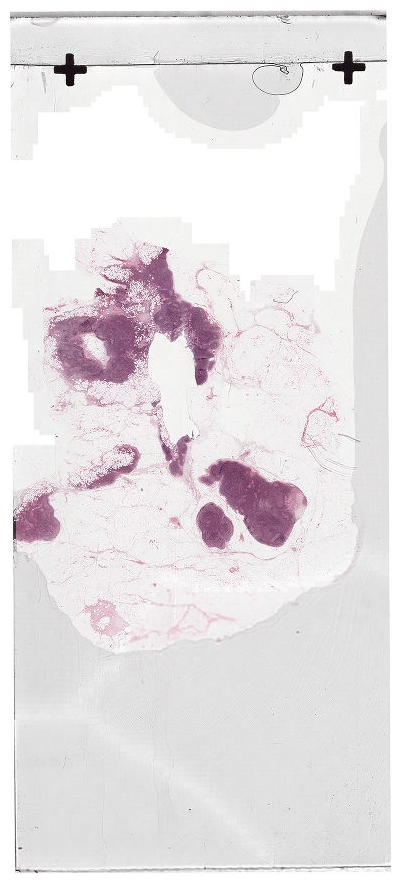

In [5]:
show_image(thumbnail)

In [6]:
from histokit.segmentation.detectors import (
    per_patch_canny_segmentation,
)


LEVEL = 8

for sample in camelyon16_dataset.samples():
    with sample.open_slide() as slide:
        thumbnail = slide.get_thumbnail(LEVEL)
        downsample = slide.level_downsamples()[LEVEL]
        # foreground_mask = clam_segmentation_otsu(5, LEVEL)(slide)
        foreground_mask = per_patch_canny_segmentation(patch_level=1, patch_size=224)(
            slide
        )

    annotations = sample.make_annotations()
    label_mask = annotations.render(thumbnail.shape[:2], downsample)

    print(label_mask.shape, foreground_mask.shape)
    print(np.unique_counts(foreground_mask))

    show_image_with_label_mask(
        thumbnail,
        label_mask,
        sample.annotation_schema.label_map,
        alpha=0.9,
    )

100%|██████████| 108186/108186 [00:22<00:00, 4764.74it/s]


(864, 382) (494, 219)
UniqueCountsResult(values=array([0., 1.]), counts=array([69558, 38628]))


TypeError: ufunc 'invert' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''